<hr/>

# [Miscellaneous Topics](https://donnievin.github.io/misc.html)
By: **Donovan Vincent Jr** - dvincen9@jh.edu <br/>
Estimated Workthrough Time: **90 mins**

<hr/>

<h1><font color="blue">Physics Informed Neural Networks [PINNs]</font></h1>

> History

The concept of using a neural network to solve differential equations was first inroduced in the 1990s in Lee and Kang's [Neural algorithm for solving differential equations](https://www.sciencedirect.com/science/article/pii/002199919090007N). They hypothesized (and simulated) ... 

These were first called PINNs ... 

---

> Goal 

The goal of a PINNS are to learn a function (via a Neural Network) that should <font color='red'> approximate the solution to a differential equation</font> $NN(x) \approx u(x)$. Because the NN is the solution, the <font color='green'> derivative of the NN (via an autograd) should match the data </font> $\frac{d}{dx}NN(x) \approx data$. However, recall from ODEs that this provides a `family` of solutions unless we account for the boundary condition in the loss function $NN(0) = IC$

---

> Why use PINNs?

* `Data Efficiency`: They work well with sparse or noisy data because the physics equation acts as a regularizer
* `Mesh-free`: Avoid complex mesh generation in high-dimensional or irregular geometries 
* `Unified Solver`: They solve forward (prediction) and inverse (identification) problems using the same framework

--- 

> Draw backs 
* Slow training: PINNS may require multiple steps to find the correct solution, and 
* Weak generalization: Doesn't extend well outside of the training domain
* Hard loss functions: It is a non-trivial to find the correct loss function

In [370]:
import copy
import scipy
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.nn.functional as F

# Simple ODE

Let's begin with a simple ODE system where we know the solution and can sample some data from: 

`Observe` $\frac{dy}{dx} = cos 2x$ ; `IC` $y(0)=1$ ; `Sol'n`

<div align="center">

$$
y(x) = \frac{1}{2} sin2x +1
$$

</div>

`Idea`: We need 2 loss conditions, 1 for the NN and one for the boundary (initial) condition

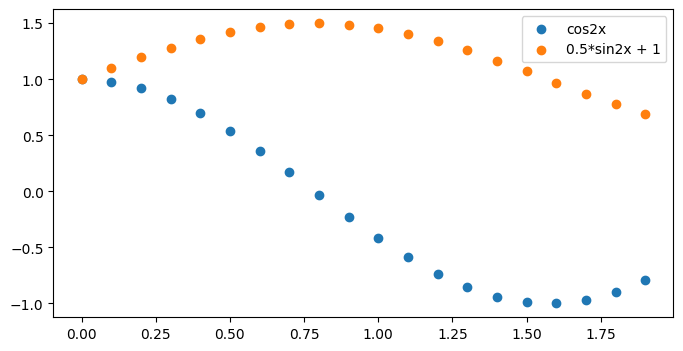

In [371]:
X = np.arange(0,2,0.1)
observed_simple_ODE = np.cos(2*X)
known_sol = np.sin(2*X)/(2) + 1

plt.figure(figsize=(8,4))
plt.scatter(X, observed_simple_ODE, label='cos2x')
plt.scatter(X,known_sol, label='0.5*sin2x + 1')
plt.legend()
plt.show()

X = torch.tensor(X, dtype=torch.float32).reshape(-1,1)
y = torch.tensor(observed_simple_ODE, dtype=torch.float32).reshape(-1,1)

In [372]:
h_dim = 64 # Try different H_dims to see that the ODE family of solutions is not unique without the IC!
simple_PINN = nn.Sequential(
    nn.Linear(1,h_dim), nn.Tanh(),
    nn.Linear(h_dim,h_dim), nn.Tanh(),
    nn.Linear(h_dim,1)
)
print(simple_PINN)

# So we can compare how all trained models did
data_only_PINN = copy.deepcopy(simple_PINN)
physics_only_PINN = copy.deepcopy(simple_PINN)

Sequential(
  (0): Linear(in_features=1, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


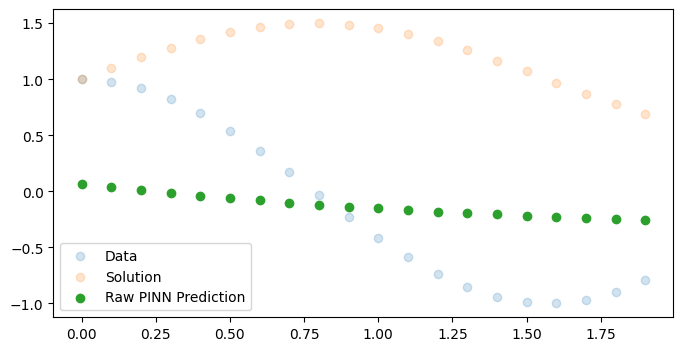

In [373]:
y_pred = simple_PINN(X)

plt.figure(figsize=(8,4))
plt.scatter(X.detach().numpy(), observed_simple_ODE, label='Data', alpha=0.2)
plt.scatter(X.detach().numpy(),known_sol, label='Solution', alpha=0.2)
plt.scatter(X.detach().numpy(), y_pred.detach().numpy(), label='Raw PINN Prediction')
plt.legend()
plt.show()

In [ ]:
##### Training loop #####
def PINN_training(PINN, num_epochs=50, mode='Full'):
    optimizer = torch.optim.Adam(PINN.parameters(), lr=0.01)
    X.requires_grad_(True)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        y_pred = PINN(X)

        print(X.shape, "X")

        # L_ODE = MSE(dydt - DATA) --> Remember NN is the ODE solution, so derivative should align with the data
        dydt_pred = torch.autograd.grad(y_pred, X, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
        print(dydt_pred.shape, "D")
        print(y.shape, "y")
        physics_loss = F.mse_loss(dydt_pred, y)
    
        # L_IC = MSE(NN(0) - 1) --> In this case, we made the initial condition 1, so it's easy
        data_loss = F.mse_loss(y_pred[0:1], torch.tensor([1.0], device=y_pred.device))

        if mode=='Full':
            loss = physics_loss + data_loss
        elif mode=='Data':
            loss = data_loss
        elif mode=='Physics':
            loss = physics_loss
        
        loss.backward() 
        optimizer.step() 

        #print(f'Epoch {epoch}, Loss: {loss.item():.4f},')
    
    return PINN

In [378]:
# TRAIN ALL MODELS 
simple_PINN = PINN_training(simple_PINN, mode='Full')
data_only_PINN = PINN_training(data_only_PINN, mode='Data')
physics_only_PINN = PINN_training(physics_only_PINN, mode='Physics')

torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])


/var/folders/4l/79n1gg7j7gzd9sw10jch20b80000gn/T/ipykernel_15384/2809032488.py:18: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  data_loss = F.mse_loss(y_pred[0:1], torch.tensor([1.0], device=y_pred.device))


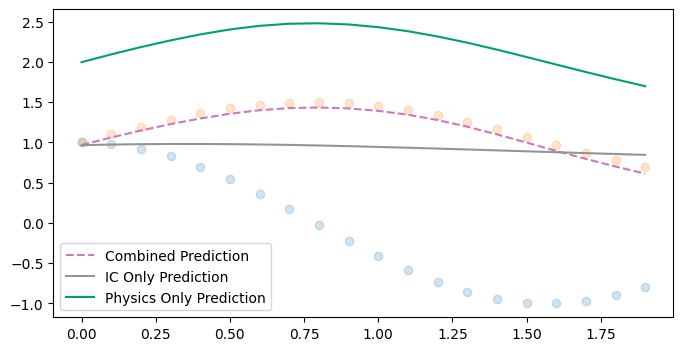

In [366]:
# Use .detach() to remove the torch.grad, and .squeeze() to remove the batch dimension
y_pred_SIMPLE = simple_PINN(X).detach().numpy().squeeze()
y_pred_DATA = data_only_PINN(X).detach().numpy().squeeze()
y_pred_PHYSICS = physics_only_PINN(X).detach().numpy().squeeze()


plt.figure(figsize=(8,4))
plt.scatter(X.detach().numpy().squeeze(), observed_simple_ODE, alpha=0.2)
plt.scatter(X.detach().numpy().squeeze(),known_sol, alpha=0.2)
sns.lineplot(x=X.detach().numpy().squeeze(), y=y_pred_SIMPLE, label='Combined Prediction', color=sns.color_palette("colorblind")[4], linestyle='--')
sns.lineplot(x=X.detach().numpy().squeeze(), y=y_pred_DATA, label='IC Only Prediction', color=sns.color_palette("colorblind")[7])
sns.lineplot(x=X.detach().numpy().squeeze(), y=y_pred_PHYSICS, label='Physics Only Prediction', color=sns.color_palette("colorblind")[2])
plt.legend()
plt.show()

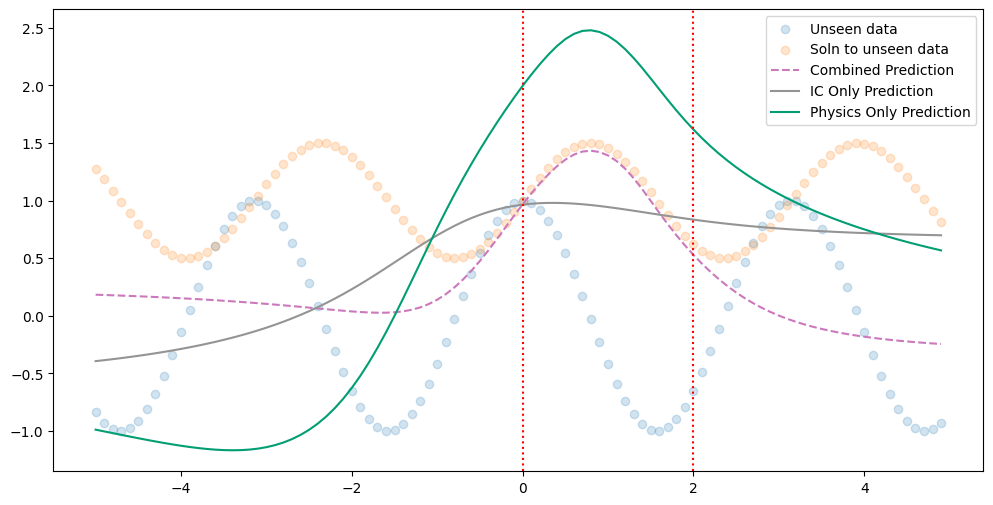

In [367]:
# Test how they performed on unseen data 
X_unseen = np.arange(-5,5,0.1)
new_data = np.cos(2*X_unseen)
new_sol = np.sin(2*X_unseen)/(2) + 1

# Feed through all trained models
X_in = torch.tensor(X_unseen, dtype=torch.float32).reshape(-1,1)
new_y_pred_SIMPLE = simple_PINN(X_in).detach().numpy().squeeze()
new_y_pred_DATA = data_only_PINN(X_in).detach().numpy().squeeze()
new_y_pred_PHYSICS = physics_only_PINN(X_in).detach().numpy().squeeze()

# Plot 
plt.figure(figsize=(12,6))
plt.scatter(X_unseen, new_data, alpha=0.2, label='Unseen data')
plt.scatter(X_unseen,new_sol, alpha=0.2, label='Soln to unseen data')
sns.lineplot(x=X_unseen, y=new_y_pred_SIMPLE, label='Combined Prediction', color=sns.color_palette("colorblind")[4], linestyle='--')
sns.lineplot(x=X_unseen, y=new_y_pred_DATA, label='IC Only Prediction', color=sns.color_palette("colorblind")[7])
sns.lineplot(x=X_unseen, y=new_y_pred_PHYSICS, label='Physics Only Prediction', color=sns.color_palette("colorblind")[2])
plt.axvline(x=0, color='red', linestyle=':')
plt.axvline(x=2, color='red', linestyle=':')
plt.legend()
plt.show()

# Mass on a spring (Simple Harmonic Motion)

The mass on a horizontal spring is a classical physics problem that intorduces students to the concept of simple Harmonic motion. In short, we have a box attached to a spring that is free to `move` from left to right. Since the object is moving, Newtons 2nd Law says: $\sum F=ma = m \frac{d^2x}{dt^2}$ and Hooke's law $F_s = -kx$, where k is the spring constant (higher equalts stiffer spring). Combining these 2 equations, we get:

<div align="center">

$$
\frac{d^2x}{dt^2} = -\frac{kx}{m}
$$

</div>


From classical physics, we know that the solution to this ODE takes the form: 

<div align="center">

$$
x(t) = A cos(\omega t + \phi)
$$

</div>

<font color='purple'> Note: x here represents that difference in distance from a reference center</font>

Let's set this problem up for this simple 2nd order ODE system where we know the solution and can sample some data from: 

`Observe` $\frac{d^2x}{dt^2} = -\frac{kx}{m}$ ; `Constraints` $k=10, m=10$ ; `Sol'n`

<div align="center">

$$
x(t) = cos(x)
$$

</div>

In [368]:
test_t = np.linspace(0, 2, 100)

train_u = np.sin(2*np.pi*train_t)/(2*np.pi) + 1
true_u = np.sin(2*np.pi*test_t)/(2*np.pi) + 1
pred_u = NN.predict(test_t).ravel()

plt.figure(figsize = (10,8))
plt.plot(train_t, train_u, 'ok', label = 'Train')
plt.plot(test_t, true_u, '-k',label = 'True')
plt.plot(test_t, pred_u, '--r', label = 'Prediction')
plt.legend(fontsize = 15)
plt.xlabel('t', fontsize = 15)
plt.ylabel('u', fontsize = 15)
plt.show()

NameError: name 'train_t' is not defined

In [ ]:
##### Training loop #####
def PINN_HM_training(PINN, num_epochs=50, mode='Full'):
    optimizer = torch.optim.Adam(PINN.parameters(), lr=0.01)
    X.requires_grad_(True)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        y_pred = PINN(X)

        # L_ODE = MSE(d2ydt2 - DATA) --> Remember NN is the ODE solution, so derivative should align with the data
        dydt_pred = torch.autograd.grad(y_pred, X, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
        d2ydt2_pred = torch.autograd.grad(dydt_pred, X, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
        physics_loss = F.mse_loss(d2ydt2_pred, y)
    
        # L_IC = MSE(NN(0) - 1) --> In this case, we made the initial condition 1, so it's easy
        data_loss = F.mse_loss(y_pred[0:1], torch.tensor([1.0], device=y_pred.device))

        if mode=='Full':
            loss = physics_loss + data_loss
        elif mode=='Data':
            loss = data_loss
        elif mode=='Physics':
            loss = physics_loss
        
        loss.backward() 
        optimizer.step() 

        #print(f'Epoch {epoch}, Loss: {loss.item():.4f},')
    
    return PINN

Epoch 0: Loss = 1.178998
Epoch 500: Loss = 0.193881
Epoch 1000: Loss = 0.172807
Epoch 1500: Loss = 0.163016
Epoch 2000: Loss = 0.150985
Epoch 2500: Loss = 0.135903
Epoch 3000: Loss = 0.125411
Epoch 3500: Loss = 0.121107
Epoch 4000: Loss = 0.120736
Epoch 4500: Loss = 0.119711


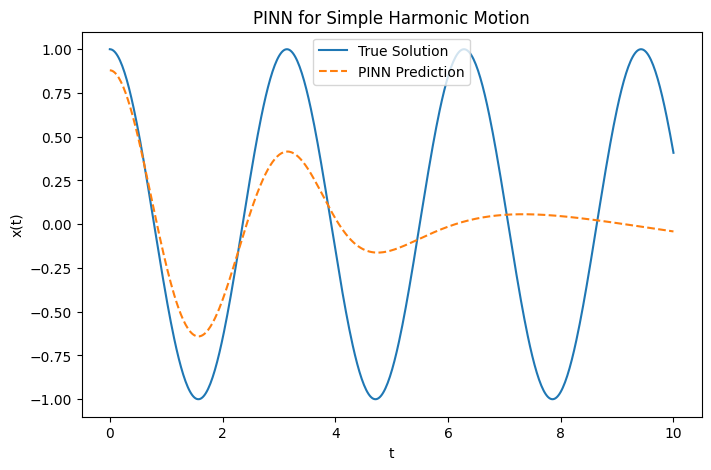

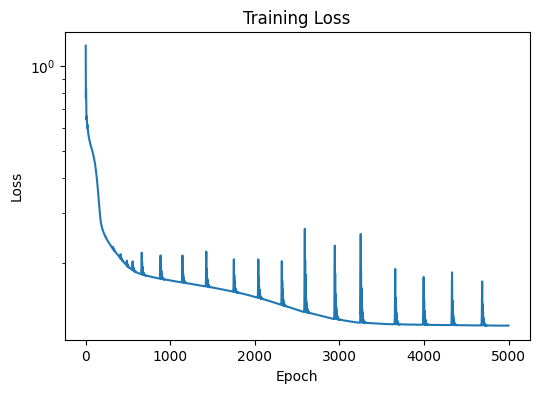

In [369]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Physical parameters
# -----------------------------------

omega = 2.0

# -----------------------------------
# Neural Network
# -----------------------------------

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, t):
        return self.net(t)

model = PINN()

# -----------------------------------
# Training points
# -----------------------------------

t_physics = torch.linspace(0, 10, 200).view(-1,1)
t_physics.requires_grad = True

# -----------------------------------
# Optimizer
# -----------------------------------

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------------
# Training loop
# -----------------------------------

loss_history = []

for epoch in range(5000):

    optimizer.zero_grad()

    x = model(t_physics) # Network prediction

    dx_dt = torch.autograd.grad(x, t_physics, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(dx_dt, t_physics, grad_outputs=torch.ones_like(dx_dt), create_graph=True)[0]

    # Physics residual
    residual = d2x_dt2 + omega**2 * x

    physics_loss = torch.mean(residual**2)

    # -----------------------------------
    # Initial conditions: x(0)=1, x'(0)=0
    # -----------------------------------

    t0 = torch.tensor([[0.0]], requires_grad=True)

    x0 = model(t0)

    dx0 = torch.autograd.grad(
        x0,
        t0,
        grad_outputs=torch.ones_like(x0),
        create_graph=True
    )[0]

    ic_loss = (x0 - 1.0)**2 + (dx0 - 0.0)**2

    # Total loss
    loss = physics_loss + ic_loss

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

# -----------------------------------
# Evaluate model
# -----------------------------------

t_test = torch.linspace(0, 10, 500).view(-1,1)

with torch.no_grad():
    pred = model(t_test).numpy()

# True solution
t_np = t_test.numpy()
true = np.cos(omega * t_np)

# -----------------------------------
# Plot solution
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(t_np, true, label="True Solution")
plt.plot(t_np, pred, '--', label="PINN Prediction")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("PINN for Simple Harmonic Motion")

plt.legend()
plt.show()

# -----------------------------------
# Plot training loss
# -----------------------------------

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

# Coupled Masses on a Spring

The previous problem was analogous to the simple 1D case, however, when we add a second mass, we now need to take into account the 2nd derivative! Let's see how to handle that using a PINN

# Fluid Flow I (Navier Stokes in 2D)

x, y 


<div align="center">

$$
\rho \frac{D \mathbf{v}}{Dt}  = -\nabla P - [\nabla \cdot \tau] + \rho \mathbf{g}
$$

$$
\frac{\partial \rho}{\partial t} + \nabla \cdot \rho \mathbf{v} = 0
$$

</div>


We will make the assumption that the fluid is an `incompressible` ($\frac{d \rho}{dt} \approx 0$) `Newtonian` () fluid flowing in only `2 Dimensions` (x and y). With these in mind, we can expand the equations and rewrite them as:
1. `Navier Stokes x-dim`: $\displaystyle \rho \left ( \frac{\partial v_x}{\partial t} + v_x \frac{\partial v_x}{\partial x} + v_y \frac{\partial v_x}{\partial y} \right) = - \frac{\partial P}{\partial x} + \rho g_x$
2. `Navier Stokes y-dim`: $\displaystyle \rho \left ( \frac{\partial v_x}{\partial t} + v_x \frac{\partial v_x}{\partial x} + v_y \frac{\partial v_x}{\partial y} \right) = - \frac{\partial P}{\partial x} + \rho g_x$
3. `Equation of Continuity`: $\displaystyle  \nabla \cdot \rho \mathbf{v} = \frac{\partial v_x }{\partial x} + \frac{\partial v_y}{\partial y}= 0$


# Fluid Flow II (Heat transfer in 2D)

Briefly, conduction, convection and radiation! 

The rule that governs conduction is known as Fourier's law of heat conduction

# Burgers' Equation

# Schrödinger Equation (3D particle in a box)

# Further References

1. [PINN:](https://i-systems.github.io/tutorial/KSNVE/220525/01_PINN.html#1.-Why-Deep-Learning-Needs-Physics%3F) by Professor Seungchul Lee
2. [Simple Harmonic Motion, Mass on a spring](https://phys.libretexts.org/Courses/Berea_College/Introductory_Physics%3A_Berea_College/13%3A_Simple_Harmonic_Motion/13.01%3A_The_motion_of_a_spring-mass_system) by LibreTexts Physics
3. [Navier Stokes Equation]()
4. [Fourier's Law of Heat Conduction](https://physicsopenlab.org/2020/04/14/temperature-logging-heat-conduction/)
5. [Burgers' Equation](https://en.wikipedia.org/wiki/Burgers'_equation) NDCG